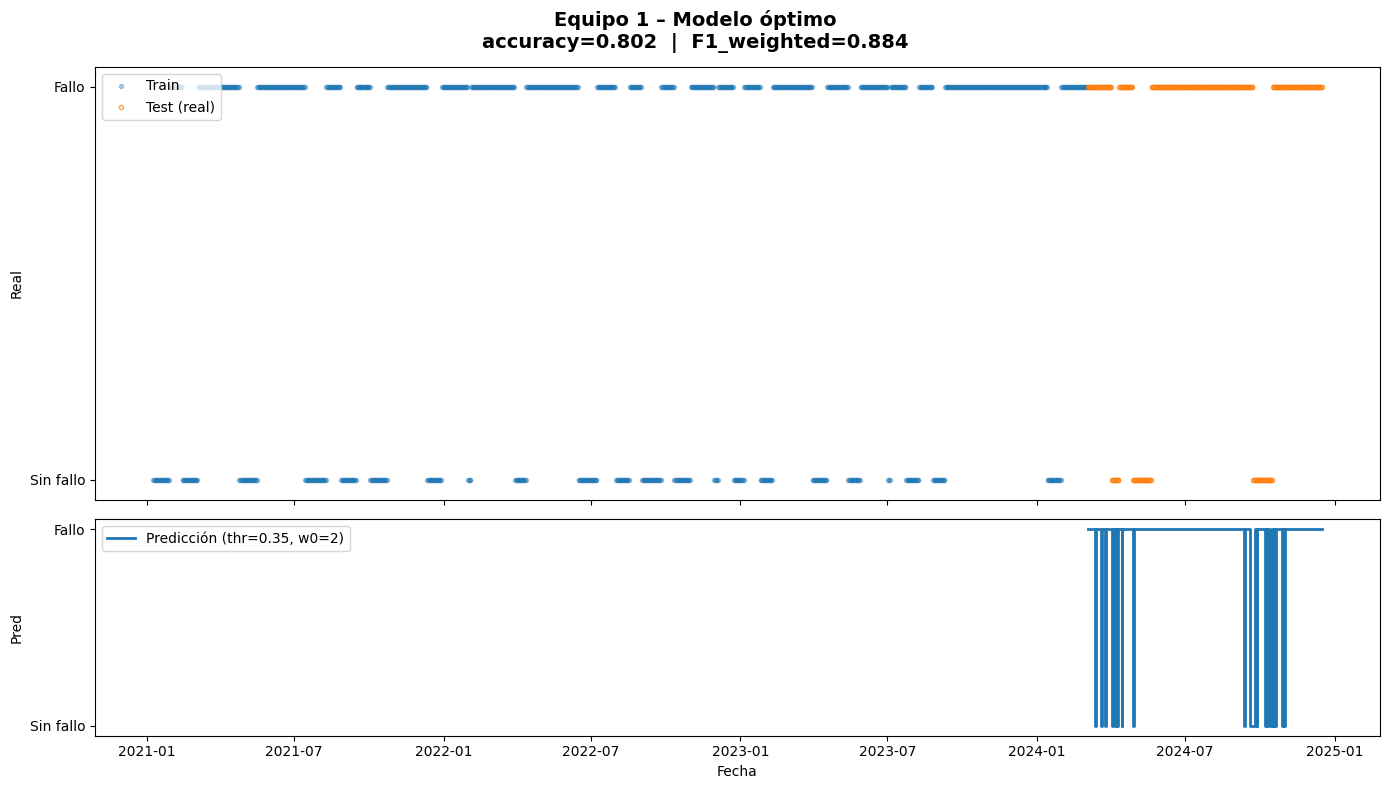


Top combinaciones ordenadas por accuracy y f1_macro:
 weight_0  threshold  accuracy  f1_macro  f1_weighted  precision_0  recall_0  precision_1  recall_1
        1       0.30     0.812     0.581        0.771        0.556     0.179        0.830     0.966
        2       0.15     0.812     0.482        0.735        1.000     0.036        0.811     1.000
        4       0.15     0.812     0.482        0.735        1.000     0.036        0.811     1.000
       10       0.15     0.812     0.482        0.735        1.000     0.036        0.811     1.000
        4       0.30     0.809     0.578        0.769        0.526     0.179        0.829     0.961
        5       0.30     0.809     0.569        0.765        0.529     0.161        0.827     0.966
        1       0.25     0.809     0.547        0.758        0.538     0.125        0.822     0.974
        4       0.25     0.809     0.547        0.758        0.538     0.125        0.822     0.974
        6       0.25     0.809     0.536      

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
)
from pathlib import Path


def cargar_equipo(csv_path: str, id_equipo: int, chunksize: int = 25_000) -> pd.DataFrame:
    partes = []
    for chunk in pd.read_csv(
        csv_path, parse_dates=["Fecha"], chunksize=chunksize, engine="python"
    ):
        partes.append(chunk[chunk["ID_Equipo"] == id_equipo])
    return pd.concat(partes, ignore_index=True)


def etiquetar_fallos(df: pd.DataFrame, horizonte: int = 15) -> pd.DataFrame:
    df = df.sort_values("Fecha").reset_index(drop=True).copy()
    correctivos = (df["Tipo_Mantenimiento"] == 1).values
    etiqueta = np.full(len(df), np.nan)
    for i in range(len(df) - horizonte):
        etiqueta[i] = 1 if correctivos[i : i + horizonte].any() else 0
    df[f"fallo_{horizonte}d"] = etiqueta
    return df.dropna(subset=[f"fallo_{horizonte}d"])


def tune_random_forest_noace(
    csv_path: str,
    id_equipo: int,
    horizonte: int = 15,
    weight_grid=(1, 2, 3, 4, 5, 6, 8, 10),
    thresholds=np.arange(0.05, 1.0, 0.05),
    top_n: int = 15,
):
    """Busca la mejor combinación class_weight/threshold sin usar ace_tools."""
    df_eq = cargar_equipo(csv_path, id_equipo)
    df_eq = etiquetar_fallos(df_eq, horizonte)

    vars_sensor = [
        "Temperatura_C",
        "Vibracion_mm_s",
        "Horas_Operativas",
        "horas_hasta_correctivo",
    ]
    X = df_eq[vars_sensor].values
    y = df_eq[f"fallo_{horizonte}d"].astype(int).values
    corte = int(len(df_eq) * 0.8)
    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]
    fechas_train = df_eq["Fecha"].iloc[:corte]
    fechas_test = df_eq["Fecha"].iloc[corte:]

    rows = []
    best_row = None
    best_score = -np.inf

    for w0 in weight_grid:
        clf = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight={0: w0, 1: 1},
        )
        clf.fit(X_train, y_train)
        proba_test = clf.predict_proba(X_test)[:, 1]

        for thr in thresholds:
            y_pred = (proba_test >= thr).astype(int)
            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average="macro")
            f1_weighted = f1_score(y_test, y_pred, average="weighted")
            precision, recall, _, _ = precision_recall_fscore_support(
                y_test, y_pred, labels=[0, 1], zero_division=0
            )
            row = {
                "weight_0": w0,
                "threshold": thr,
                "accuracy": acc,
                "f1_macro": f1_macro,
                "f1_weighted": f1_weighted,
                "precision_0": precision[0],
                "recall_0": recall[0],
                "precision_1": precision[1],
                "recall_1": recall[1],
            }
            rows.append(row)

            if (acc >= 0.80) and (f1_weighted >= 0.75):
                if f1_macro > best_score:
                    best_score = f1_macro
                    best_row = row.copy()

    df_metrics = pd.DataFrame(rows)

    

    if best_row is None:
        print(
            "❌ Ninguna combinación cumple accuracy ≥ 0.80 y F1_weighted ≥ 0.75."
        )
        return None, None, df_metrics

    # Mejor combinación
    w0_best = best_row["weight_0"]
    thr_best = best_row["threshold"]

    clf_best = RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight={0: w0_best, 1: 1}
    )
    clf_best.fit(X_train, y_train)
    proba_test = clf_best.predict_proba(X_test)[:, 1]
    y_pred_best = (proba_test >= thr_best).astype(int)

    acc_best = accuracy_score(y_test, y_pred_best)
    f1_best = f1_score(y_test, y_pred_best)

    # Gráfica resultados
    # … (entrenamiento igual que antes) …

    fig, (ax_real, ax_pred) = plt.subplots(
    nrows=2, ncols=1, figsize=(14, 8), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
    
    )


    # --- eje superior: datos reales --------------------------
    ax_real.plot(fechas_train, y_train, '.', label='Train', alpha=0.35)
    ax_real.plot(fechas_test,  y_test,  '.', label='Test (real)', alpha=0.7,
             markerfacecolor='none', markeredgecolor='tab:orange')
    ax_real.set_ylabel('Real')
    ax_real.set_yticks([0, 1])
    ax_real.set_yticklabels(['Sin fallo', 'Fallo'])
    ax_real.legend(loc='upper left')

    # --- eje inferior: predicción -----------------------------
    ax_pred.step(fechas_test, y_pred_best, where='post',
             label=f'Predicción (thr={thr_best:.2f}, w0={w0_best})',
             linewidth=2)
    ax_pred.set_ylabel('Pred')
    ax_pred.set_yticks([0, 1])
    ax_pred.set_yticklabels(['Sin fallo', 'Fallo'])
    ax_pred.legend(loc='upper left')
    
    # ajustes finales
    plt.suptitle(
    f'Equipo {id_equipo} – Modelo óptimo\n'
    f'accuracy={acc_best:.3f}  |  F1_weighted={f1_best:.3f}',
    fontsize=14, fontweight='bold'
    )
    plt.xlabel('Fecha')
    plt.tight_layout()
    plt.show()


    # Mostrar top_n filas ordenadas
    top_df = (
        df_metrics.sort_values(["accuracy", "f1_macro"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    print("\nTop combinaciones ordenadas por accuracy y f1_macro:")
    print(top_df.round(3).to_string(index=False))

    print("\n✅ Mejor combinación encontrada:")
    for k, v in best_row.items():
        print(f"- {k}: {v:.3f}" if isinstance(v, float) else f"- {k}: {v}")

    return best_row, top_df, df_metrics


# ----------------- Ejecutamos para Equipo 1 -----------------
best_params, top_table, all_metrics = tune_random_forest_noace(
    "../data/Datos_limpios.csv", id_equipo=1, horizonte=15
)





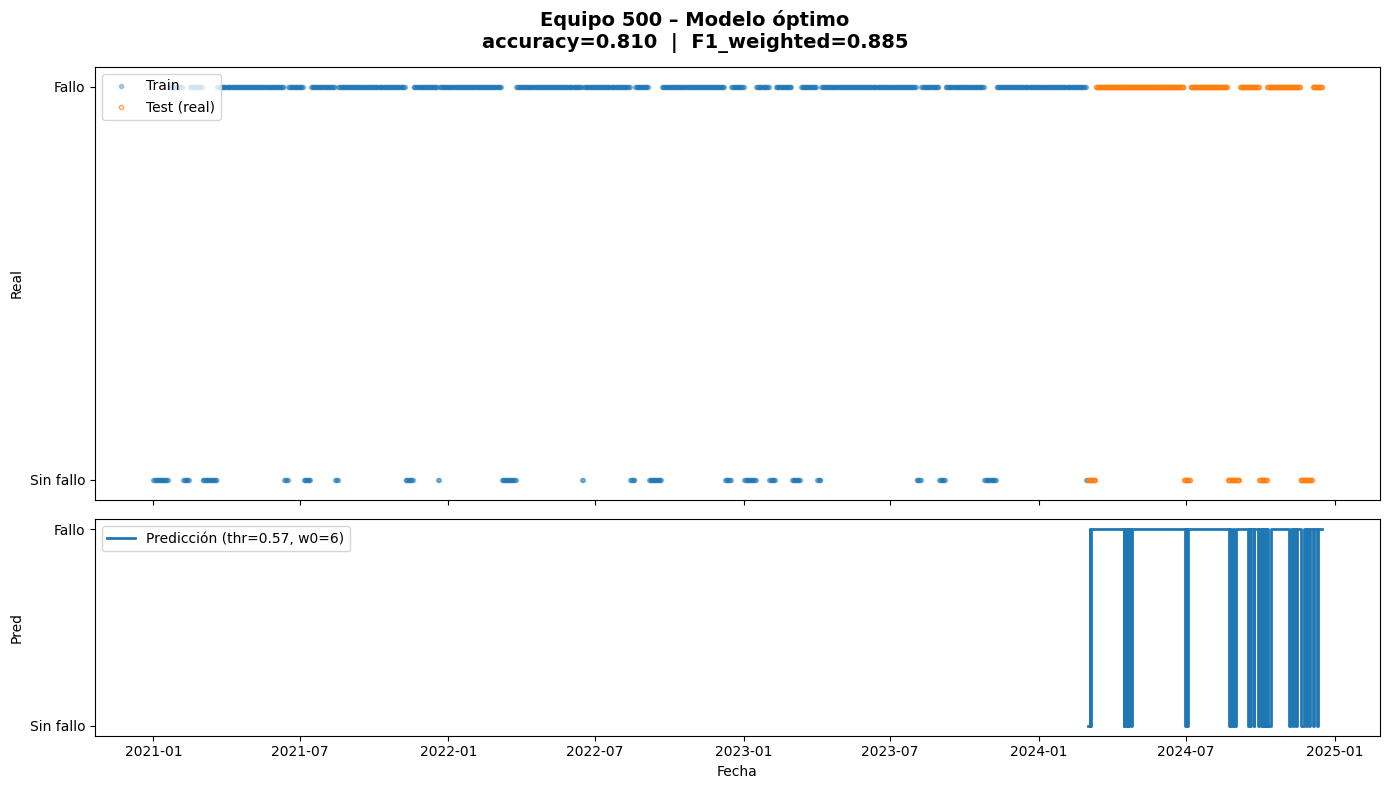


Top combinaciones ordenadas por accuracy y f1_macro:
 weight_0  threshold  accuracy  f1_macro  f1_weighted  precision_0  recall_0  precision_1  recall_1
        4       0.53     0.824     0.662        0.802        0.613     0.328        0.849     0.948
        4       0.51     0.824     0.655        0.800        0.621     0.310        0.847     0.953
        5       0.55     0.821     0.670        0.804        0.583     0.362        0.854     0.935
        5       0.53     0.821     0.658        0.800        0.594     0.328        0.849     0.944
       10       0.53     0.821     0.658        0.800        0.594     0.328        0.849     0.944
       10       0.55     0.817     0.661        0.799        0.571     0.345        0.851     0.935
        4       0.55     0.817     0.655        0.797        0.576     0.328        0.848     0.940
        3       0.51     0.817     0.642        0.792        0.586     0.293        0.843     0.948
        3       0.49     0.817     0.627      

In [17]:
best, top, _ = tune_random_forest_noace(
    "../data/Datos_limpios.csv",
    id_equipo=500,
    horizonte=15,
    weight_grid=(1,2,3,4,5,6,8,10),  # puedes ampliarlo
    thresholds=np.arange(0.05, 1.0, 0.02),
    top_n=20,
)


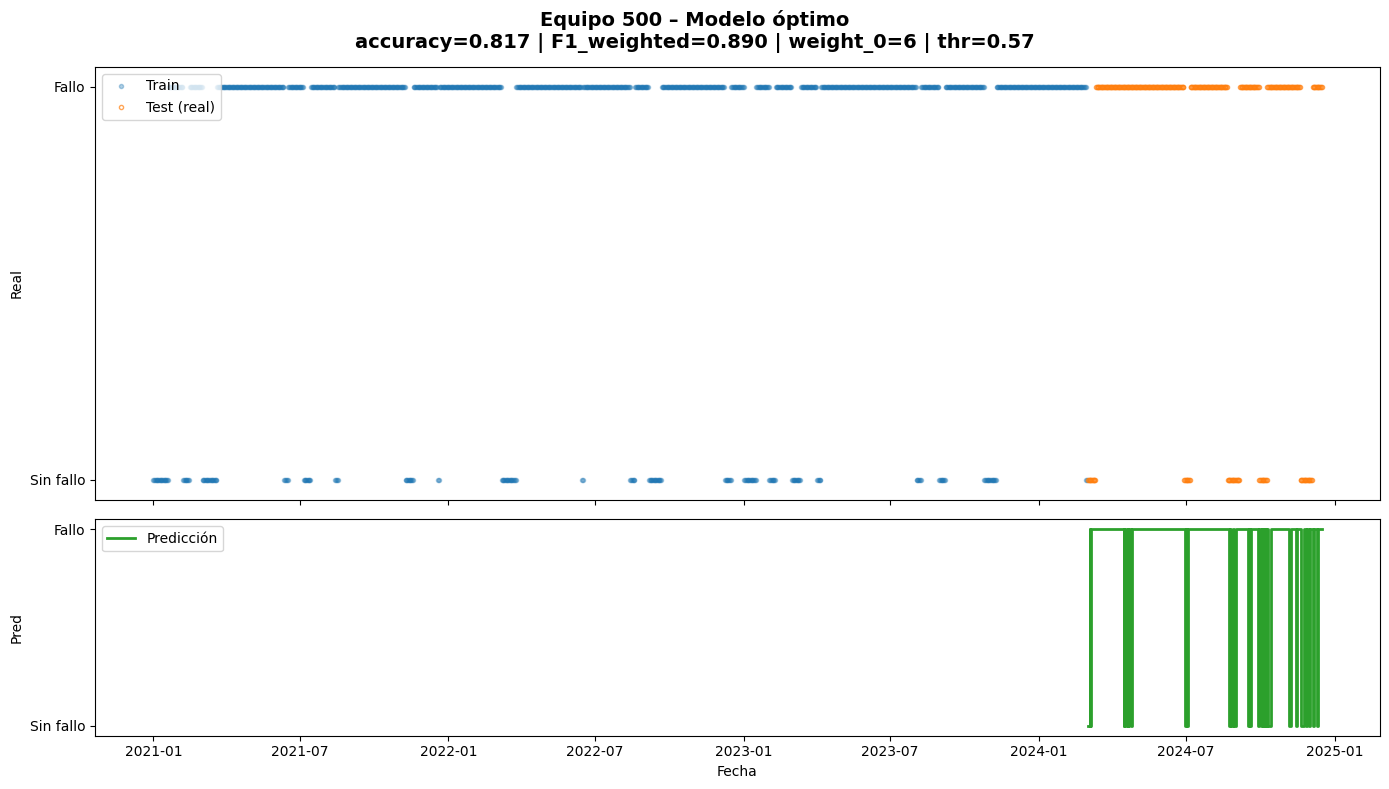

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from pathlib import Path

# ---------- Parámetros ----------
csv_path = "../data/Datos_limpios.csv"  # ruta absoluta en el entorno
id_equipo = 500
horizonte = 15
w0_best = 6               # class_weight óptimo hallado
thr_best = 0.57           # threshold óptimo hallado
n_estimators = 300
random_state = 42

# ---------- Funciones auxiliares ----------
def cargar_equipo(csv_path: str, id_equipo: int, chunksize: int = 25_000) -> pd.DataFrame:
    partes = []
    for chunk in pd.read_csv(csv_path, parse_dates=["Fecha"], chunksize=chunksize, engine="python"):
        partes.append(chunk[chunk["ID_Equipo"] == id_equipo])
    return pd.concat(partes, ignore_index=True)

def etiquetar_fallos(df: pd.DataFrame, horizonte: int = 15) -> pd.DataFrame:
    df = df.sort_values("Fecha").reset_index(drop=True).copy()
    correctivos = (df["Tipo_Mantenimiento"] == 1).values
    etiqueta = np.full(len(df), np.nan)
    for i in range(len(df) - horizonte):
        etiqueta[i] = 1 if correctivos[i : i + horizonte].any() else 0
    df[f"fallo_{horizonte}d"] = etiqueta
    return df.dropna(subset=[f"fallo_{horizonte}d"])

# ---------- Carga y preparación ----------
df_eq = cargar_equipo(csv_path, id_equipo)
df_eq = etiquetar_fallos(df_eq, horizonte)

vars_sensor = ["Temperatura_C", "Vibracion_mm_s", "Horas_Operativas", "horas_hasta_correctivo"]
X = df_eq[vars_sensor].values
y = df_eq[f"fallo_{horizonte}d"].astype(int).values
corte = int(len(df_eq) * 0.8)
X_train, X_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]
fechas_train = df_eq["Fecha"].iloc[:corte]
fechas_test = df_eq["Fecha"].iloc[corte:]

# ---------- Entrenamiento del modelo óptimo ----------
clf_best = RandomForestClassifier(
    n_estimators=n_estimators,
    random_state=random_state,
    class_weight={0: w0_best, 1: 1},
)
clf_best.fit(X_train, y_train)
proba_test = clf_best.predict_proba(X_test)[:, 1]
y_pred_best = (proba_test >= thr_best).astype(int)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

# ---------- Gráfica mejorada (dos ejes) ----------
fig, (ax_real, ax_pred) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]}
)

# Eje superior: valores reales
ax_real.plot(fechas_train, y_train, '.', alpha=0.35, label='Train')
ax_real.plot(fechas_test, y_test, '.', alpha=0.7,
             markerfacecolor='none', markeredgecolor='tab:orange',
             label='Test (real)')
ax_real.set_ylabel('Real')
ax_real.set_yticks([0, 1])
ax_real.set_yticklabels(['Sin fallo', 'Fallo'])
ax_real.legend(loc='upper left')

# Eje inferior: predicción
ax_pred.step(fechas_test, y_pred_best, where='post', linewidth=2,
             color='tab:green', label='Predicción')
ax_pred.set_ylabel('Pred')
ax_pred.set_yticks([0, 1])
ax_pred.set_yticklabels(['Sin fallo', 'Fallo'])
ax_pred.legend(loc='upper left')

# Título y ajustes
plt.suptitle(
    f'Equipo {id_equipo} – Modelo óptimo\n'
    f'accuracy={acc_best:.3f} | F1_weighted={f1_best:.3f} | weight_0={w0_best} | thr={thr_best}',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()
